In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import os
import time

# --- 設定 ---
DATASET_NAME = 'imagenette/320px-v2' 
BATCH_SIZE = 128
IMG_SIZE = 256

# ===================================================
# 步驟 0: GPU 檢查與配置
# ===================================================
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # 設定 GPU 記憶體增長
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        
        # 設置策略
        strategy = tf.distribute.OneDeviceStrategy(device="/gpu:0")
        print(f"✅ 成功偵測到 {len(gpus)} 個 GPU！將使用第一個 GPU 進行訓練。")
        print(f"當前使用的 TensorFlow 版本: {tf.__version__}")
    except RuntimeError as e:
        print(f"❌ GPU 設定失敗: {e}")
        strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")
else:
    print("⚠️ 未偵測到 GPU。訓練將在 CPU 上運行。")
    strategy = tf.distribute.OneDeviceStrategy(device="/cpu:0")

# ===================================================
# 步驟 1: 載入資料集和資訊 (極限兼容寫法)
# ===================================================
print(f"--- 載入與檢查資料集：{DATASET_NAME} ---")

# 獲取系統預設的資料夾路徑 (通常是 ~/tensorflow_datasets)
default_data_dir = os.path.join(os.path.expanduser('~'), 'tensorflow_datasets')

# tfds.load 會自動檢查本地是否有資料
# try_to_map_dataset=True 能加速檢查過程
dataset_results = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    as_supervised=True,
    shuffle_files=True,      
    with_info=True, 
    data_dir=default_data_dir, # 明確指定路徑，增加穩定性
    download=True              # 它會自動偵測「下載過就跳過」
)

(ds_train_full, ds_validation_full), ds_info = dataset_results

train_count = ds_info.splits['train'].num_examples
validation_count = ds_info.splits['validation'].num_examples
class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes

print(f"✅ 資料集已就緒。")
print(f"本地路徑: {default_data_dir}")
print(f"訓練集數量: {train_count:,} | 驗證集數量: {validation_count:,}")
train_count = ds_info.splits['train'].num_examples
class_names = ds_info.features['label'].names
num_classes = ds_info.features['label'].num_classes





✅ 成功偵測到 1 個 GPU！將使用第一個 GPU 進行訓練。
當前使用的 TensorFlow 版本: 2.10.0
--- 載入與檢查資料集：imagenette/320px-v2 ---
✅ 資料集已就緒。
本地路徑: C:\Users\wtml6\tensorflow_datasets
訓練集數量: 9,469 | 驗證集數量: 3,925


--- 正在精確統計類別分布，請稍候 (這會花一點點時間讀取資料) ---


C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 39006 (\N{CJK UNIFIED IDEOGRAPH-985E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 31281 (\N{CJK UNIFIED IDEOGRAPH-7A31}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:40: UserWarning: Glyph 29255 (\

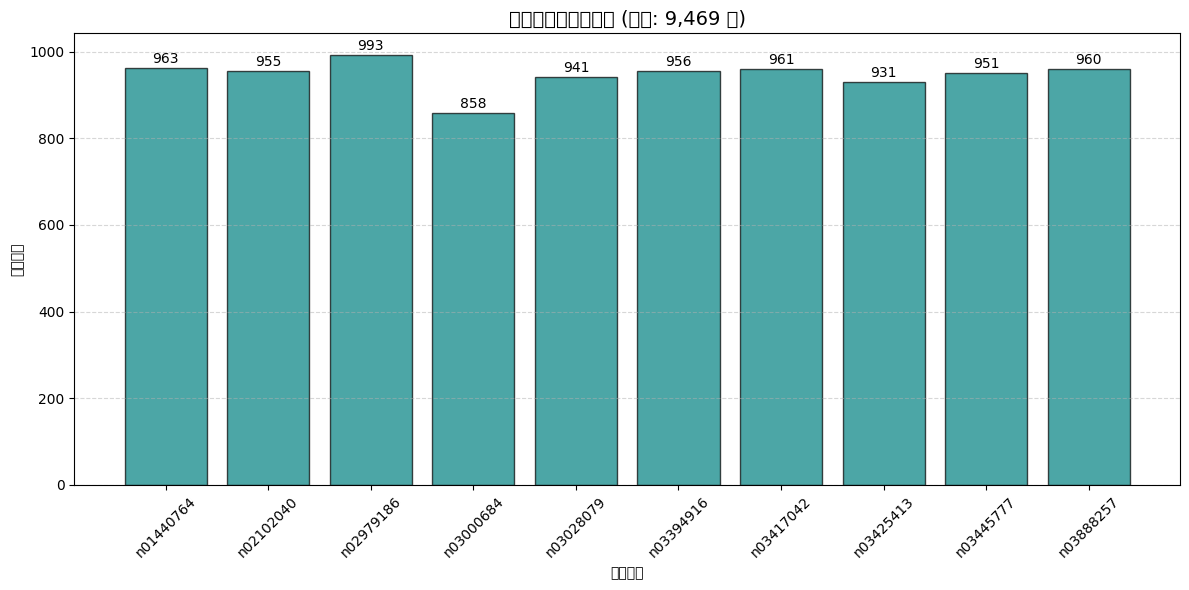


--- 隨機抽取展示 (順序已與統計圖同步) ---


C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:72: UserWarning: Glyph 38568 (\N{CJK UNIFIED IDEOGRAPH-96A8}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:72: UserWarning: Glyph 27231 (\N{CJK UNIFIED IDEOGRAPH-6A5F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:72: UserWarning: Glyph 25277 (\N{CJK UNIFIED IDEOGRAPH-62BD}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:72: UserWarning: Glyph 21462 (\N{CJK UNIFIED IDEOGRAPH-53D6}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\wtml6\AppData\Local\Temp\ipykernel_14068\1320350452.py:72: UserWarning: Glyph 22294 (\N{CJK UNIFIED IDEOGRAPH-5716}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=

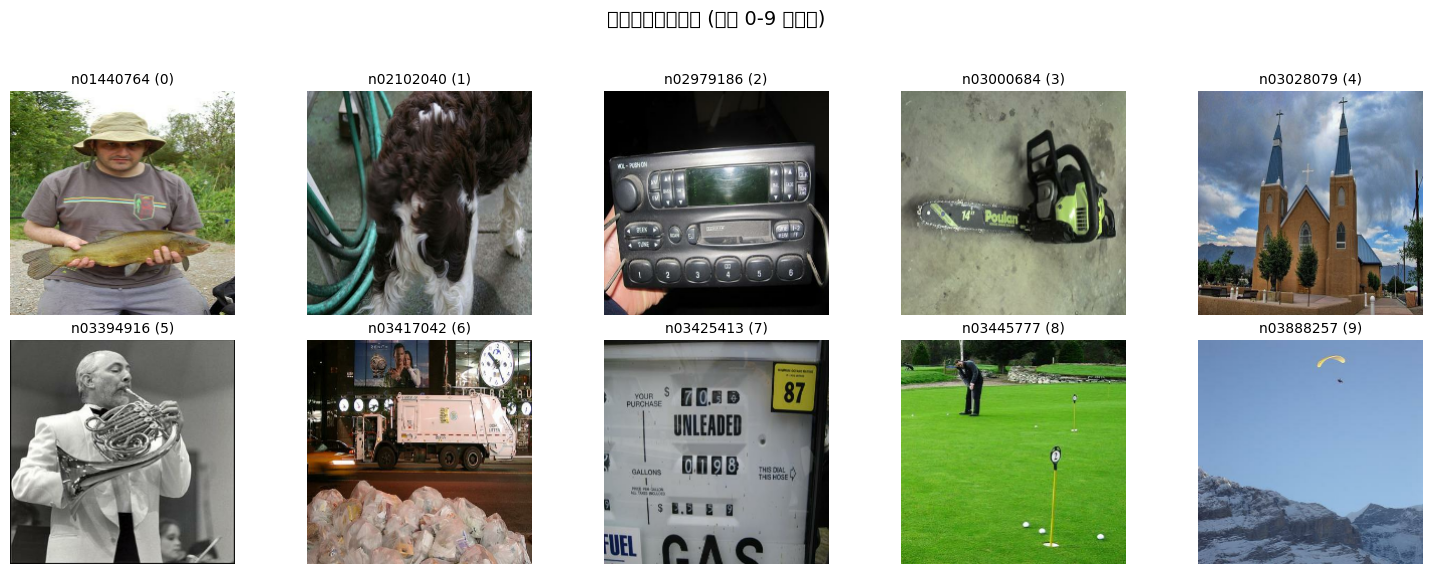


✅ 資料集已完成優化處理、橫向統計圖與隨機展示已就緒。


In [2]:
# ===================================================
# 2.1 定義預處理函數
# ===================================================
def normalize_img(image, label):
    # 只要 resize 就好
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # 確保是浮點數，但千萬「不要」加 / 255.0
    return tf.cast(image, tf.float32), label

# ===================================================
# 步驟 2.2: 類別統計(橫向)與隨機抽取展示
# ===================================================

import collections

# A. 實地盤點：精確統計訓練集中的類別分布
print("--- 正在精確統計類別分布，請稍候 (這會花一點點時間讀取資料) ---")
label_counts = collections.Counter()
for _, label in ds_train_full:
    label_counts[label.numpy()] += 1

# 準備繪圖數據
counts = [label_counts[i] for i in range(num_classes)]
total_actual = sum(counts)

# 繪製長條圖 (採用 MobileNet 的縱向風格，但保留你的 Teal 顏色)
plt.figure(figsize=(12, 6))
bars = plt.bar(class_names, counts, color='teal', alpha=0.7, edgecolor='black')

# 在柱狀圖上方顯示具體數值
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, f'{int(yval)}', ha='center', va='bottom')

plt.title(f"訓練集真實類別分布 (總計: {total_actual:,} 張)", fontsize=14)
plt.xlabel("類別名稱")
plt.ylabel("圖片張數")
plt.xticks(rotation=45) # 名稱太長時旋轉 45 度避免重疊
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ---
# B. 隨機抽取並以「同步順序」展示
print("\n--- 隨機抽取展示 (順序已與統計圖同步) ---")

sampled_images = {}
# 增加抽樣範圍確保 10 類都能抽到
for image, label in ds_train_full.shuffle(2000).take(3000):
    label_int = label.numpy()
    if label_int not in sampled_images:
        # 展示用高解析度 224x224
        img_high_res = tf.image.resize(image, [224, 224])
        sampled_images[label_int] = img_high_res.numpy().astype(np.uint8)
    
    if len(sampled_images) == num_classes:
        break

# 繪製圖片矩陣：強制依照索引 0 到 9 排序
plt.figure(figsize=(15, 6))
for i in range(num_classes):
    if i in sampled_images:
        image = sampled_images[i]
        class_name = class_names[i]
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(image)
        plt.title(f"{class_name} ({i})", fontsize=10)
        plt.axis('off')

plt.suptitle(f"隨機抽取圖片展示 (順序 0-9 同步化)", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
# ===================================================
# 2.3 準備最終的訓練/驗證 Dataset (優化方案一版本)
# ===================================================
BUFFER_SIZE = tf.data.AUTOTUNE 

def augment(image, label):
    # 在 CPU 上進行高效增強，避免 GPU While_loop 警告
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    return image, label

# 重新載入數據
(ds_train, ds_validation) = tfds.load(
    DATASET_NAME,
    split=['train', 'validation'],
    shuffle_files=True,
    as_supervised=True,
)

# 訓練集管線：Map(正規化) -> Cache -> Map(增強) -> Shuffle -> Batch -> Prefetch
ds_train = ds_train.map(normalize_img, num_parallel_calls=BUFFER_SIZE)
ds_train = ds_train.cache() # 快取原始數據
ds_train = ds_train.map(augment, num_parallel_calls=BUFFER_SIZE) # 隨機增強在 CPU 跑
ds_train = ds_train.shuffle(buffer_size=1000) 
ds_train = ds_train.batch(BATCH_SIZE)
ds_train = ds_train.prefetch(BUFFER_SIZE)

# 驗證集管線
ds_validation = ds_validation.map(normalize_img, num_parallel_calls=BUFFER_SIZE)
ds_validation = ds_validation.batch(BATCH_SIZE)
ds_validation = ds_validation.prefetch(BUFFER_SIZE)

print(f"\n✅ 資料集已完成優化處理、橫向統計圖與隨機展示已就緒。")

3.1:隨機選擇要不要翻轉
因為傳統只會讓機器死背，但這樣會讓LOSS下降很多，所以翻轉圖片，讓機器學習狗的耳朵長什麼樣，鼻子在哪...讓它更加準確

In [ ]:
import time
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0 # 導入 Google 的強大大腦

# --- 完美日誌 Callback：保留所有進度條且不截斷 ---
class FullHistoryLogger(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.train_start_time = time.time()
        print(f"🚀 訓練啟動時間: {time.strftime('%H:%M:%S', time.localtime())}")
        print("=" * 70)

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.epoch_start_time
        acc = logs.get('accuracy', 0)
        val_acc = logs.get('val_accuracy', 0)
        
        print(f"\n✨ [Epoch {epoch + 1}] 結算: 耗時 {duration:.2f}s | Acc: {acc:.4f} | Val_Acc: {val_acc:.4f}")
        print("-" * 70)

# ===================================================
# 3.1 & 3.2 模型定義與編譯 (升級為 Google 遷移學習架構)
# ===================================================
with tf.device('/gpu:0'):
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        
        # 第一組卷積與池化：捕捉基礎線條
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # 第二組卷積：捕捉局部形狀
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        
        # 第三組卷積：捕捉複雜特徵
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.GlobalAveragePooling2D(), # 代替 Flatten，減少參數
        
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("✅ 自定義 CNN 模型已就緒。")
model.summary()
# ===================================================
# 3.3 訓練模型 (保留進度條與紀錄)
# ===================================================
EPOCHS = 15
history_logger = FullHistoryLogger()

print(f"\n--- 開始訓練 (目標: {EPOCHS} 個週期) ---")

# 這次 5070 會跑得更有意義，準確度會上升得很快
history = model.fit(
    ds_train,
    epochs=EPOCHS,
    validation_data=ds_validation,
    verbose=2,                  
    callbacks=[history_logger] 
)

print(f"\n🎉 訓練全數完成！總耗時: {(time.time() - history_logger.train_start_time)/60:.2f} 分鐘")

✅ EfficientNetB0 模型已定義並準備就緒！
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lambda (Lambda)             (None, 256, 256, 3)       0         
                                                                 
 efficientnetb0 (Functional)  (None, 8, 8, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 1280)             5120      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)             


--- 訓練結果分析 ---
最低驗證損失 (Min Validation Loss): 0.0184
模型達到最低驗證損失的**最佳時間 (Best Epoch)** 是第 15 週期。


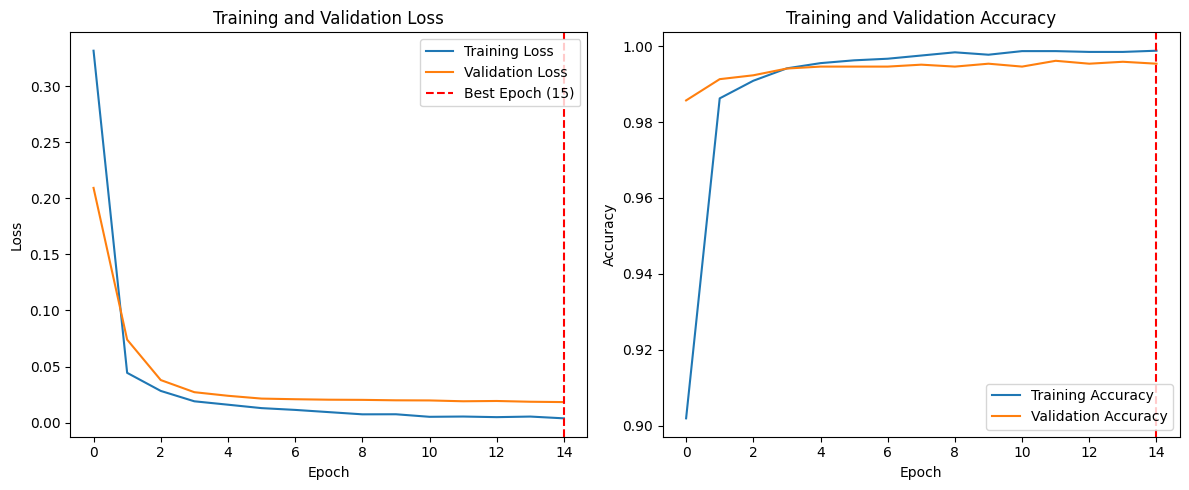

✅ 已生成圖表：training_history_imagenette.png


In [4]:
# 4.1 找出最佳時間
val_loss = history.history['val_loss']
min_val_loss = min(val_loss)
best_epoch = np.argmin(val_loss) + 1 # 週期從 1 開始

print(f"\n--- 訓練結果分析 ---")
print(f"最低驗證損失 (Min Validation Loss): {min_val_loss:.4f}")
print(f"模型達到最低驗證損失的**最佳時間 (Best Epoch)** 是第 {best_epoch} 週期。")

# 4.2 繪製 Accuracy 和 Loss 曲線圖
def plot_history(history, filename='training_history_imagenette.png'):
    """繪製訓練過程中的 Accuracy 和 Loss 曲線圖。"""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # 繪製 Loss 曲線
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=best_epoch - 1, color='r', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')

    # 繪製 Accuracy 曲線
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=best_epoch - 1, color='r', linestyle='--')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

plot_history(history)
print(f"✅ 已生成圖表：training_history_imagenette.png")